In [1]:
from pinnsform.util import *
from pinnsform.model import PINNsformer
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
%matplotlib inline

def load_csv_to_numpy(file_path):
    df = pd.read_csv(file_path, header=None, index_col=None, sep=",")
    return np.array(df.values)

In [2]:
problem_domain = ([0, 2*np.pi], [0, 1])
problem_name = "1Dreaction"
device='cpu'

train_points = (51, 51)
mesh, boundaries = generate_mesh_object(train_points, domain=problem_domain, device=device, full_requires_grad=True, border_requires_grad=False, num_seq_steps=5, seq_step_size=1e-3)

In [3]:
base_dir_pre = os.getcwd()
base_dir = os.path.join(base_dir_pre, '..')

script_labels = ["PINNFORMER_VAR_TS_LBFGS_200", "PINNFORMER_DeltaT_TS_LBFGS_200", "PINNFORMER_SeqK_TS_LBFGS_100"]
experiment_paths = {
    "PINNsformer" : os.path.join(base_dir, "results", "PINNFORMER_VAR_TS_LBFGS_200", "run", "PINNsformer"),
    "PINNsformerNoAttention" : os.path.join(base_dir, "results", "PINNFORMER_VAR_TS_LBFGS_200", "run", "PINNsformerNoAttention"),
    "NoSequence_PINNsformer" : os.path.join(base_dir, "results", "PINNFORMER_VAR_TS_LBFGS_200", "run", "NoSequence_PINNsformer"),
    "PINNsformerOnlyEncoder" :  os.path.join(base_dir, "results", "PINNFORMER_VAR_TS_LBFGS_200", "OnlyEncoder", "PINNsformerOnlyEncoder"),
    "PINNsformerSmall1Head" : os.path.join(base_dir, "results", "PINNFORMER_VAR_TS_LBFGS_200", "small1head", "smallPINNsformer1head")
}

In [4]:
device = 'cpu'

pinnsformers = PINNsformer(d_out=1, d_hidden=512, d_model=32, N=1, heads=2).to(device)

NUM_SEEDS = 100
INIT_SEEDS = np.array(range(NUM_SEEDS))

def mean_init_prediction(model, mesh):
    return np.mean(f(model, mesh).detach().cpu().numpy())

In [5]:
def error_list(path, error_index=0):
    rmae_list = []
    for i in INIT_SEEDS:
        rmae_path = os.path.join(path, f"seed_{i}", "error.csv")
        data = load_csv_to_numpy(rmae_path)
        rmae_list.append(float(data[1,error_index]))
    return rmae_list

In [6]:
def mip_list(path, model, mesh):
    mips = []
    for i in INIT_SEEDS:
        weight_path = os.path.join(path, f"seed_{i}", "model_at_0.pth")
        model.load_state_dict(torch.load(weight_path))
        mips.append(mean_init_prediction(model, mesh))
    return mips

In [7]:
def scatterplot(x_data, y_data, file_name, title=None, x_label=None, y_label=None):
  plt.figure(figsize=(4, 3))
  plt.grid(True)

  # Create the scatter plot
  plt.scatter(x_data, y_data)

  # Set labels and title (if provided)
  if title:
    plt.title(title)
  if x_label:
    plt.xlabel(x_label)
  if y_label:
    plt.ylabel(y_label)

  # Display and save the plot
  plt.tight_layout()
  plt.savefig('./plots/' + problem_name + '_scatterplot_' + file_name + '.png', dpi=400)
  plt.show()

In [8]:
def histogram(data, file_name):
    plt.figure(figsize=(4, 3))
    # Create a histogram
    plt.grid(True)
    plt.hist(data, bins=np.arange(0,1.1,0.1), edgecolor='black')
    #plt.title("rMAE ")
    plt.xlabel("rMSE")
    plt.ylabel("Count")
    plt.ylim(0,100)
    # Display the plot
    plt.tight_layout()
    plt.savefig('./plots/'+problem_name+'_histogram_'+file_name+'.png', dpi=400)
    plt.show()


/upb/users/p/pauldf/profiles/unix/cs/.local/lib/python3.9/site-packages/torch/cuda/__init__.py:611: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


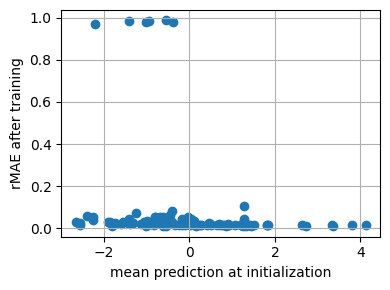

In [9]:
mip = mip_list(experiment_paths["PINNsformer"], pinnsformers, mesh)
rmae = error_list(experiment_paths["PINNsformer"], error_index=0)
scatterplot(mip, rmae, 'PINNsformer_mip_rmae', x_label='mean prediction at initialization', y_label='rMAE after training')

In [10]:
mip

[-0.23947456,
 0.48961073,
 3.3590837,
 -0.75731856,
 -1.8040264,
 0.8610542,
 -1.5970905,
 -0.656626,
 -0.18248343,
 0.49681905,
 -0.9518022,
 -1.4392016,
 0.76562035,
 -2.5707054,
 -0.024002403,
 -0.6291802,
 1.2293903,
 -1.7488278,
 1.8455428,
 0.26421523,
 0.03049546,
 0.0044308943,
 1.8107035,
 0.25638768,
 3.8122911,
 -0.18255875,
 0.9261043,
 -0.98991644,
 -0.41018867,
 0.9074219,
 -2.2533972,
 1.2739319,
 -1.329109,
 -1.8648627,
 1.3173696,
 -0.487573,
 0.40505436,
 1.2043799,
 -0.6845698,
 -0.1719779,
 2.6243536,
 -0.40331912,
 -0.9277393,
 -0.45918292,
 -2.6606965,
 0.72153103,
 -1.3953745,
 -0.9644697,
 -1.0276983,
 -1.4646633,
 -0.80706143,
 1.225363,
 -0.031134538,
 1.5203154,
 1.4254744,
 -0.6196951,
 -0.8389207,
 1.8123006,
 0.8861436,
 3.3428538,
 -0.34804097,
 -0.5450349,
 0.07560286,
 -0.17590156,
 2.7319183,
 -0.38287762,
 1.0765541,
 0.09971306,
 1.2782845,
 -0.8123232,
 1.2479889,
 -0.5453675,
 1.4512231,
 -2.5510457,
 -2.2533367,
 -1.5531073,
 -1.1374362,
 1.21226

In [27]:
miprmae_data

array([[-0.23947456,  0.01335441],
       [ 0.48961073,  0.01945303],
       [ 3.35908365,  0.01261547],
       [-0.75731856,  0.02927776],
       [-1.80402637,  0.01260922],
       [ 0.86105418,  0.01237779],
       [-1.59709048,  0.01801588],
       [-0.65662599,  0.03899986],
       [-0.18248343,  0.01417729],
       [ 0.49681905,  0.01354056],
       [-0.95180219,  0.9841923 ],
       [-1.43920159,  0.02538336],
       [ 0.76562035,  0.01698911],
       [-2.57070541,  0.0144526 ],
       [-0.0240024 ,  0.03183451],
       [-0.62918019,  0.05170686],
       [ 1.22939026,  0.01931842],
       [-1.74882782,  0.02302723],
       [ 1.84554279,  0.01734505],
       [ 0.26421523,  0.01585318],
       [ 0.03049546,  0.04469862],
       [ 0.00443089,  0.04532865],
       [ 1.81070352,  0.01630209],
       [ 0.25638768,  0.01743863],
       [ 3.81229115,  0.01546004],
       [-0.18255875,  0.04150025],
       [ 0.92610431,  0.01613711],
       [-0.98991644,  0.03342096],
       [-0.41018867,

In [ ]:
def mean_std_error_for_mipthreshold(mip_data, error_data, mip_threshold = 0.5):
    mip_error_data = np.stack((mip_data, error_data), axis=1)

    below_mean = np.mean(mip_error_data[mip_error_data[:,0]<0.5][:,1])
    below_std = np.std(mip_error_data[mip_error_data[:,0]<0.5][:,1])
    above_mean = np.mean(mip_error_data[mip_error_data[:,0]>0.5][:,1])
    above_std = np.std(mip_error_data[mip_error_data[:,0]>0.5][:,1])
    
    return below_mean, below_std, above_mean, above_std

0.1137445700367647
0.27014650596849926


0.018930350218750003
0.0163902284467841


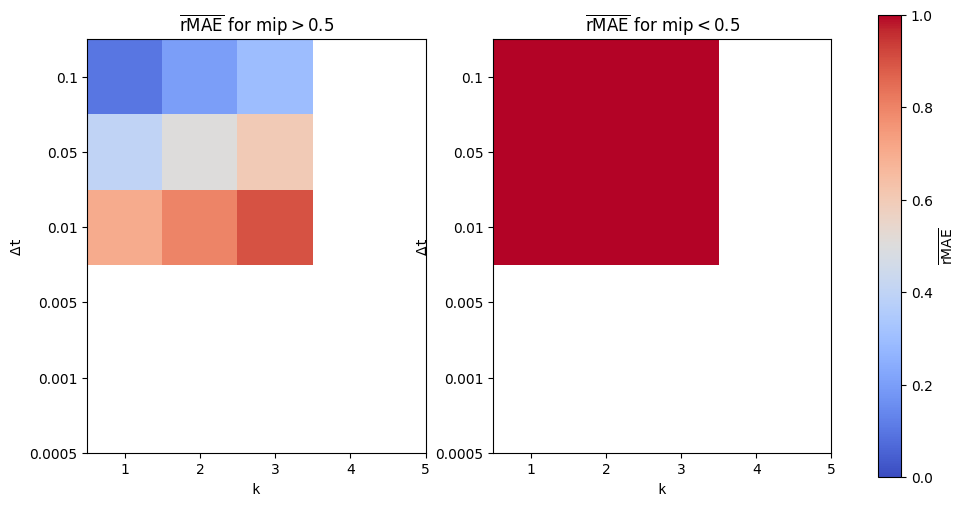

In [53]:
# Assuming you have the values for "k" and "Δt"
k_values = [1, 2, 3, 4, 5]
delta_t_values = [0.1, 0.05, 0.01, 0.005, 0.001, 0.0005]

# Assuming you have two matrices:
mean_rmae_above_05 = np.array([[0.1, 0.2, 0.3],
                               [0.4, 0.5, 0.6],
                               [0.7, 0.8, 0.9]])

mean_rmae_below_05 = np.array([[1.0, 1.1, 1.2],
                               [1.3, 1.4, 1.5],
                               [1.6, 1.7, 1.8]])


# Create the heatmaps
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Heatmap for mip > 0.5
im = axs[0].imshow(mean_rmae_above_05, cmap='coolwarm', vmin=0.0, vmax=1.0)
axs[0].set_title(r'$\overline{\text{rMAE}}$ for $\text{mip} > 0.5$')

# Heatmap for mip < 0.5
im = axs[1].imshow(mean_rmae_below_05, cmap='coolwarm', vmin=0.0, vmax=1.0)
axs[1].set_title(r'$\overline{\text{rMAE}}$ for $\text{mip} < 0.5$')

# Add colorbars
cbar = fig.colorbar(im, ax=axs)
cbar.set_label(r'$\overline{\text{rMAE}}$')

# Add axis labels and ticks
for ax in axs:
    ax.set_xticks(np.arange(len(k_values)))
    ax.set_yticks(np.arange(len(delta_t_values)))
    ax.set_xticklabels(k_values)
    ax.set_yticklabels(delta_t_values)
    ax.set_xlabel(r'$\mathtt{k}$')
    ax.set_ylabel(r'$\Delta \mathtt{t}$')

plt.show()